In [2]:
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.signal import welch
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import warnings

# Suppress heavy MNE warnings
warnings.filterwarnings("ignore")
mne.set_log_level("WARNING")

# ==========================================
# PATHS (Update these to match your system)
# ==========================================
ROOT_DIR = Path("/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split")
CSV_DIR = ROOT_DIR / "csv_fixed_channels_fczpz_updated"  # Your fixed CSV folder
OUTPUT_DIR = Path("./nmt4k_analysis_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Standard Channels for Analysis (10-20 System)
STANDARD_CHANNELS = [
    'FP1', 'FP2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2',
    'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'FZ', 'CZ', 'PZ'
]

# Frequency Bands
BANDS = {
    "Delta": (0.5, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta": (13, 30),
    "Gamma": (30, 45)
}

print("✅ Setup Complete. Output folder created.")

✅ Setup Complete. Output folder created.


In [3]:
from pathlib import Path

# Folder 1 (the one you want to check): missing files will be reported here
FOLDER_1 = CSV_DIR
# Folder 2 (reference): files expected to exist in folder 1
FOLDER_2 = ROOT_DIR / "csv_fixed_channels_fczpz"

# Collect CSV filenames (non-recursive). Change to rglob('*.csv') if needed.
files_1 = {p.name for p in FOLDER_1.glob("*.csv") if p.is_file()}
files_2 = {p.name for p in FOLDER_2.glob("*.csv") if p.is_file()}

missing_in_folder_1 = sorted(files_2 - files_1)

for name in missing_in_folder_1:
    print(name)


mh_2019_0000316.csv
mh_2019_0000583.csv


In [ ]:
def get_files_df(root):
    """Walks the directory to index all EDF files."""
    records = []
    # 1. Train Split
    for label in ["normal", "abnormal"]:
        path = root / "train" / label
        if path.exists():
            for f in path.glob("*.edf"):
                records.append({"file_id": f.stem, "path": str(f), "split": "train", "label": label})
    
    # 2. Eval/Test Split
    # Checks for both 'eval' and 'test' folder names just in case
    for split_name in ["eval", "test"]:
        for label in ["normal", "abnormal"]:
            path = root / split_name / label
            if path.exists():
                for f in path.glob("*.edf"):
                    records.append({"file_id": f.stem, "path": str(f), "split": "test", "label": label})
            
    return pd.DataFrame(records)

print("✅ Helper functions defined.")

✅ Helper functions defined.


In [4]:
def compute_psd_welch(raw, fmin=0.5, fmax=50):
    """Computes PSD using Welch's method for standard channels."""
    # Select only standard channels that exist in this file
    available_chs = [ch for ch in raw.ch_names if ch.upper() in STANDARD_CHANNELS]
    if not available_chs:
        return None, None, None
        
    raw_sub = raw.copy().pick_channels(available_chs)
    data = raw_sub.get_data()
    sfreq = raw_sub.info['sfreq']
    
    # Welch's method (2-second window)
    # NOTE: Scipy's welch does NOT accept fmin/fmax directly.
    freqs, psd = welch(data, fs=sfreq, nperseg=int(2*sfreq), axis=-1)
    
    # --- FIX: Manually slice the data to keep only fmin-fmax ---
    idx_good = np.logical_and(freqs >= fmin, freqs <= fmax)
    freqs = freqs[idx_good]
    psd = psd[..., idx_good]
    
    return freqs, psd, available_chs

def extract_band_powers(freqs, psd, ch_names):
    """Calculates relative band power features for ML."""
    features = {}
    total_power = np.sum(psd, axis=-1, keepdims=True)
    
    # 1. Band Powers (Delta, Theta, etc.)
    for band, (f_low, f_high) in BANDS.items():
        # Find indices for this specific band
        idx_band = np.logical_and(freqs >= f_low, freqs <= f_high)
        
        # If no frequencies match (e.g., band is outside our computed range), skip or set to 0
        if not np.any(idx_band):
            features[f"{band}_mean"] = 0.0
            features[f"{band}_max"] = 0.0
            continue
            
        band_power = np.sum(psd[:, idx_band], axis=-1)
        # Relative Power (Band / Total)
        rel_power = band_power / (total_power.flatten() + 1e-9)
        
        # Aggregate across channels (Mean & Max)
        features[f"{band}_mean"] = np.mean(rel_power)
        features[f"{band}_max"] = np.max(rel_power)
    
    # 2. Alpha Peak Location (8-13 Hz)
    idx_alpha = np.logical_and(freqs >= 8, freqs <= 13)
    if np.any(idx_alpha):
        # Mean PSD across channels, then find peak
        alpha_psd = np.mean(psd[:, idx_alpha], axis=0) 
        alpha_freqs = freqs[idx_alpha]
        if len(alpha_freqs) > 0:
            peak_loc = alpha_freqs[np.argmax(alpha_psd)]
            features["Alpha_Peak_Hz"] = peak_loc
        else:
            features["Alpha_Peak_Hz"] = np.nan
    else:
        features["Alpha_Peak_Hz"] = np.nan
        
    return features

print("✅ Helper functions defined (Fixed for Scipy).")

✅ Helper functions defined (Fixed for Scipy).


In [5]:
# Index all files
files_df = get_files_df(ROOT_DIR)
print(f"Found {len(files_df)} files.")

# Storage lists
signal_metrics = []
ml_features = []
ml_labels = []

print("Starting processing... (This may take time)")
for idx, row in tqdm(files_df.iterrows(), total=len(files_df)):
    f_path = row["path"]
    f_id = row["file_id"]
    
    try:
        # Load EDF (Headers only first)
        raw = mne.io.read_raw_edf(f_path, verbose=False, preload=False)
        dur = raw.times[-1]
        
        # Load 60s of data (Crop for speed)
        # Change tmax to None for full analysis
        tmax = min(dur, 60)
        raw_crop = raw.copy().crop(tmin=0, tmax=tmax).load_data()
        
        # --- A) Signal Quality Checks ---
        freqs, psd, used_chs = compute_psd_welch(raw_crop)
        
        if psd is not None:
            # Check for flat channels (simple artifact detection)
            data = raw_crop.get_data()
            flat_chs = np.sum(np.std(data, axis=1) < 1e-6)
            
            # --- D) ML Feature Extraction ---
            feats = extract_band_powers(freqs, psd, used_chs)
            
            # Store Metrics
            signal_metrics.append({
                "file_id": f_id,
                "duration": dur,
                "n_flat_channels": flat_chs,
                "alpha_peak": feats.get("Alpha_Peak_Hz"),
                "SNR_proxy_delta": feats.get("Delta_mean") # High delta often noise in awake adults
            })
            
            # Store for ML
            feats["file_id"] = f_id
            ml_features.append(feats)
            ml_labels.append(1 if row["label"] == "abnormal" else 0)
            
    except Exception as e:
        # Catch corrupted files
        print(f"Skipped {f_id}: {e}")

# Convert to DataFrame
df_signals = pd.DataFrame(signal_metrics)
df_features = pd.DataFrame(ml_features)
df_features["label"] = ml_labels

# Save Results
df_signals.to_csv(OUTPUT_DIR / "signal_quality_metrics.csv", index=False)
df_features.to_csv(OUTPUT_DIR / "ml_features_baseline.csv", index=False)

print(f"✅ Processing Done. Processed {len(df_signals)} files.")
df_signals.head()

Found 4000 files.
Starting processing... (This may take time)


 87%|████████▋ | 3478/4000 [00:39<00:06, 86.50it/s]

Skipped mh_2024_0004037: index -1 is out of bounds for axis 0 with size 0


100%|██████████| 4000/4000 [00:45<00:00, 88.53it/s]


✅ Processing Done. Processed 3999 files.


,file_id,duration,n_flat_channels,alpha_peak,SNR_proxy_delta
0,mh_2019_0001538,821.995,22,10.0,0.000014
1,mh_2019_0002037,925.995,22,8.0,0.000037
2,mh_2019_0001240,806.995,21,9.0,0.000014
3,mh_2024_0004207,1271.995,22,8.0,0.000058
4,mh_2024_0004269,965.995,22,9.5,0.000005


Aggregating Event Data...


100%|██████████| 957/957 [00:01<00:00, 875.53it/s]


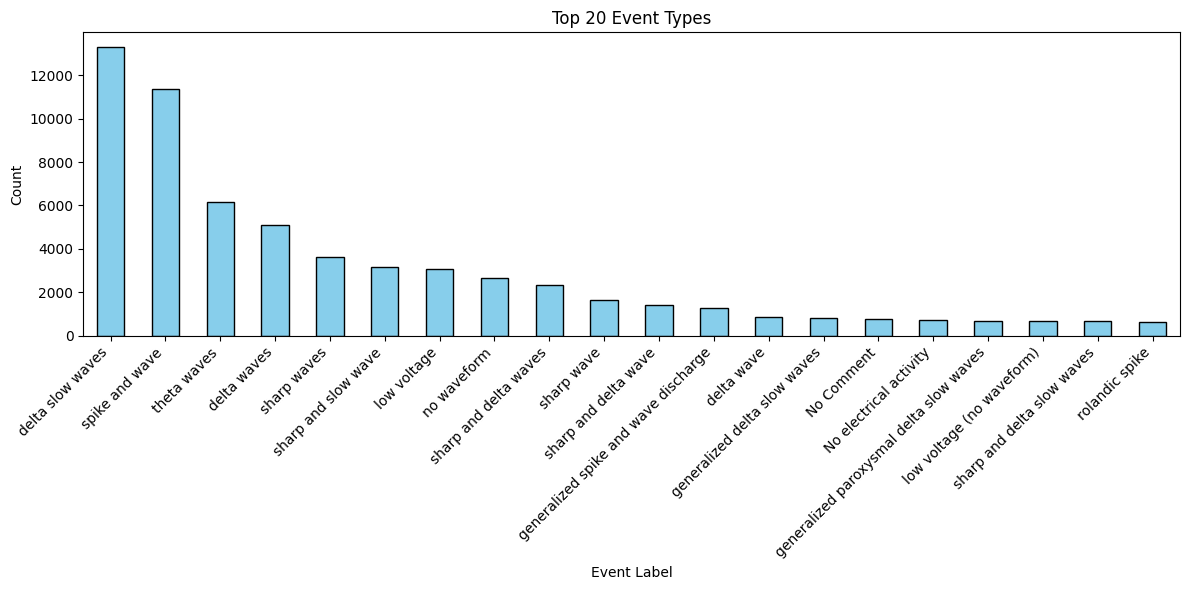

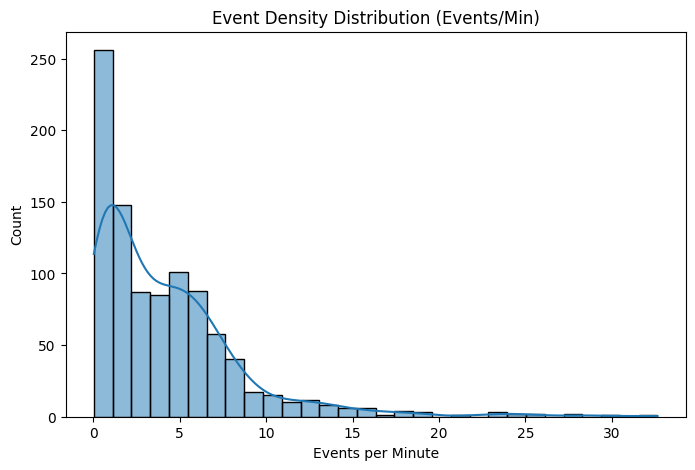

✅ Event Analysis Saved.


In [6]:
all_events = []

# Load all CSVs that match our processed files
print("Aggregating Event Data...")
processed_ids = set(df_signals["file_id"])

for csv_path in tqdm(list(CSV_DIR.glob("*.csv"))):
    if csv_path.stem in processed_ids:
        try:
            df = pd.read_csv(csv_path)
            # Ensure we have a label column (adjust 'Comment' if your column name differs)
            if "Comment" in df.columns:
                df["file_id"] = csv_path.stem
                all_events.append(df[["file_id", "Comment", "Start time", "End time"]])
        except:
            pass

if all_events:
    df_events = pd.concat(all_events, ignore_index=True)
    
    # 1. Event Histogram
    plt.figure(figsize=(12, 6))
    df_events["Comment"].value_counts().head(20).plot(kind="bar", color='skyblue', edgecolor='black')
    plt.title("Top 20 Event Types")
    plt.xlabel("Event Label")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "event_histogram.png")
    plt.show()
    
    # 2. Event Density
    # Merge with duration from signal metrics
    event_counts = df_events.groupby("file_id").size().reset_index(name="event_count")
    density_df = event_counts.merge(df_signals[["file_id", "duration"]], on="file_id")
    density_df["events_per_min"] = density_df["event_count"] / (density_df["duration"] / 60)
    
    plt.figure(figsize=(8, 5))
    sns.histplot(density_df["events_per_min"], bins=30, kde=True)
    plt.title("Event Density Distribution (Events/Min)")
    plt.xlabel("Events per Minute")
    plt.savefig(OUTPUT_DIR / "event_density.png")
    plt.show()
    
    print("✅ Event Analysis Saved.")
else:
    print("⚠️ No event CSVs found matching the IDs.")

--- Baseline Model Performance ---
              precision    recall  f1-score   support

      Normal       0.79      0.97      0.87       923
    Abnormal       0.56      0.12      0.19       277

    accuracy                           0.78      1200
   macro avg       0.67      0.54      0.53      1200
weighted avg       0.73      0.78      0.71      1200

ROC-AUC Score: 0.6931


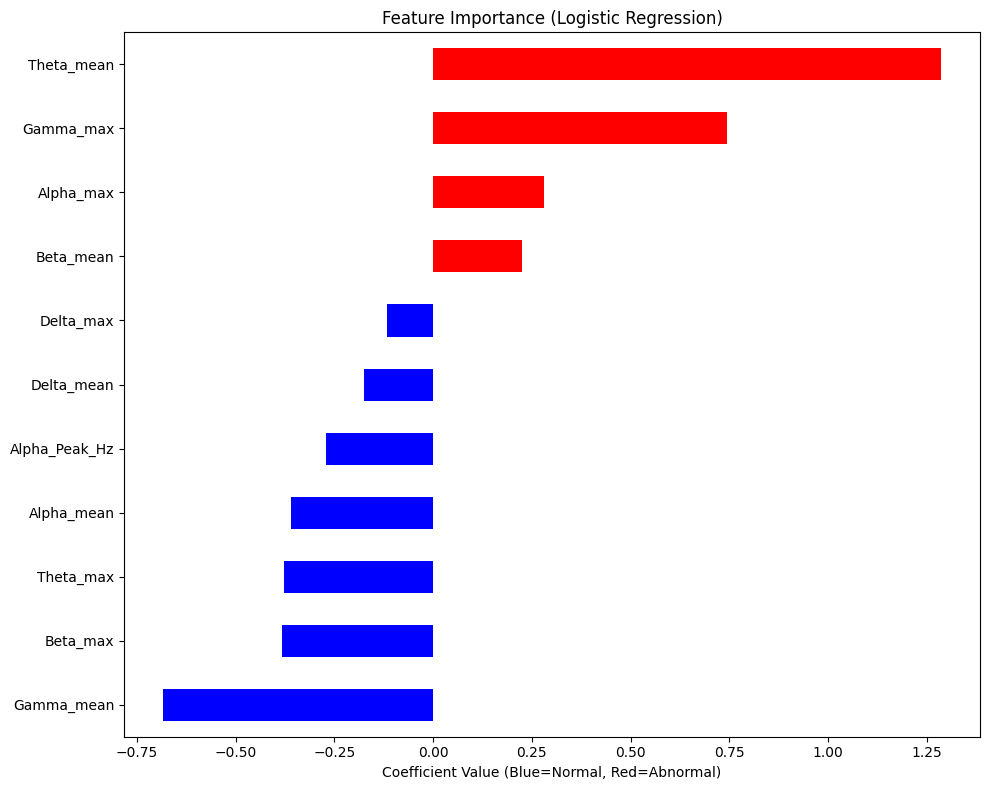

In [7]:
# Prepare Data
X = df_features.drop(columns=["file_id", "label"]).fillna(0)
y = df_features["label"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scaling (Important for Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Report
print("--- Baseline Model Performance ---")
print(classification_report(y_test, y_pred, target_names=["Normal", "Abnormal"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Feature Importance Plot
plt.figure(figsize=(10, 8))
coeffs = pd.Series(model.coef_[0], index=X.columns).sort_values()
coeffs.plot(kind="barh", color=np.where(coeffs > 0, 'r', 'b'))
plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value (Blue=Normal, Red=Abnormal)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ml_feature_importance.png")
plt.show()

In [11]:
import numpy as np
import pandas as pd
import mne
from scipy.signal import welch
from pathlib import Path
from tqdm import tqdm

ROOT = Path("/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split")

EDF_DIRS = [
    ROOT / "train" / "abnormal",
    ROOT / "train" / "normal",
    ROOT / "eval"  / "abnormal",
    ROOT / "eval"  / "normal",
]

OUT = Path("./nmt4k_signal_quality")
OUT.mkdir(exist_ok=True)


In [12]:
def bandpower(psd, freqs, fmin, fmax):
    idx = np.logical_and(freqs >= fmin, freqs <= fmax)
    return np.trapz(psd[idx], freqs[idx])

def compute_channel_metrics(signal, sfreq):
    freqs, psd = welch(signal, sfreq, nperseg=1024)

    total = bandpower(psd, freqs, 0.5, 45)
    delta = bandpower(psd, freqs, 0.5, 4)
    theta = bandpower(psd, freqs, 4, 8)
    alpha = bandpower(psd, freqs, 8, 13)
    beta  = bandpower(psd, freqs, 13, 30)
    gamma = bandpower(psd, freqs, 30, 45)

    hf_noise = gamma
    snr = 10 * np.log10((total + 1e-12) / (hf_noise + 1e-12))

    # Alpha peak
    alpha_idx = np.logical_and(freqs >= 8, freqs <= 13)
    alpha_peak = freqs[alpha_idx][np.argmax(psd[alpha_idx])] if alpha > 0 else np.nan

    return {
        "delta_rel": delta / total,
        "theta_rel": theta / total,
        "alpha_rel": alpha / total,
        "beta_rel":  beta / total,
        "gamma_rel": gamma / total,
        "snr_db": snr,
        "alpha_peak_hz": alpha_peak
    }



In [13]:
file_rows = []
channel_rows = []

for edf_dir in EDF_DIRS:
    for edf in tqdm(list(edf_dir.glob("*.edf")), desc=str(edf_dir)):
        try:
            raw = mne.io.read_raw_edf(edf, preload=True, verbose=False)
            data = raw.get_data()
            sfreq = raw.info["sfreq"]
            ch_names = raw.ch_names

            # Inter-channel correlation
            corr = np.corrcoef(data)
            mean_corr = np.nanmean(np.abs(corr[np.triu_indices_from(corr, 1)]))

            snrs = []

            for i, ch in enumerate(ch_names):
                m = compute_channel_metrics(data[i], sfreq)
                snrs.append(m["snr_db"])

                channel_rows.append({
                    "file": edf.name,
                    "channel": ch,
                    **m
                })

            file_rows.append({
                "file": edf.name,
                "split": edf_dir.parts[-2],
                "label": edf_dir.parts[-1],
                "sfreq": sfreq,
                "duration_min": raw.times[-1] / 60,
                "mean_snr_db": np.mean(snrs),
                "min_snr_db": np.min(snrs),
                "mean_inter_channel_corr": mean_corr
            })

        except Exception as e:
            print("Failed:", edf.name, e)


/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/train/abnormal: 100%|██████████| 500/500 [00:49<00:00, 10.10it/s]
/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/train/normal: 100%|██████████| 2500/2500 [04:41<00:00,  8.89it/s]
/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/eval/abnormal: 100%|██████████| 460/460 [01:00<00:00,  7.61it/s]
/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/eval/normal:  86%|████████▌ | 463/540 [01:03<00:08,  8.74it/s]

Failed: mh_2024_0004037.edf index -1 is out of bounds for axis 0 with size 0


/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/eval/normal: 100%|██████████| 540/540 [01:13<00:00,  7.37it/s]


In [14]:
df_file = pd.DataFrame(file_rows)
df_chan = pd.DataFrame(channel_rows)

df_file.to_csv(OUT / "signal_quality_file_level.csv", index=False)
df_chan.to_csv(OUT / "signal_quality_channel_level.csv", index=False)

print("Saved:")
print(OUT / "signal_quality_file_level.csv")
print(OUT / "signal_quality_channel_level.csv")


Saved:
nmt4k_signal_quality/signal_quality_file_level.csv
nmt4k_signal_quality/signal_quality_channel_level.csv


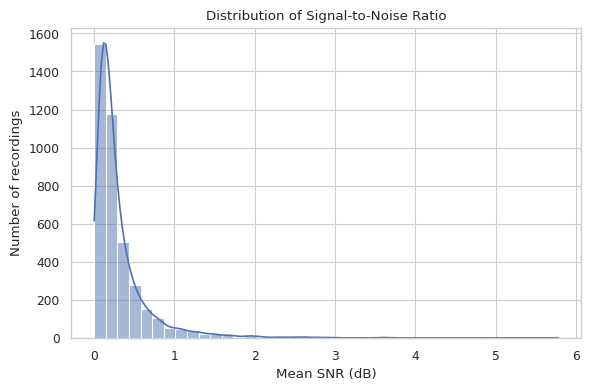

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="paper")

df_file = pd.read_csv("nmt4k_signal_quality/signal_quality_file_level.csv")
df_chan = pd.read_csv("nmt4k_signal_quality/signal_quality_channel_level.csv")

plt.figure(figsize=(6,4))
sns.histplot(df_file["mean_snr_db"], bins=40, kde=True)
plt.xlabel("Mean SNR (dB)")
plt.ylabel("Number of recordings")
plt.title("Distribution of Signal-to-Noise Ratio")
plt.tight_layout()
plt.savefig(OUT / "fig_snr_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


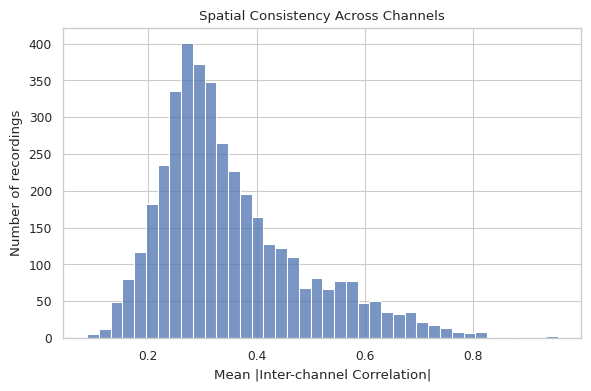

In [22]:
plt.figure(figsize=(6,4))
sns.histplot(df_file["mean_inter_channel_corr"], bins=40)
plt.xlabel("Mean |Inter-channel Correlation|")
plt.ylabel("Number of recordings")
plt.title("Spatial Consistency Across Channels")
plt.tight_layout()
plt.savefig(OUT / "fig_interchannel_corr.png", dpi=300, bbox_inches="tight")
plt.show()


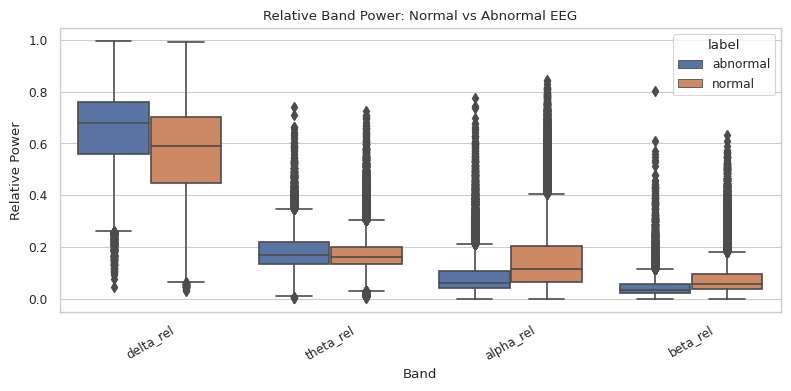

In [23]:
bands = ["delta_rel", "theta_rel", "alpha_rel", "beta_rel"]

df_plot = df_chan.merge(
    df_file[["file","label"]],
    left_on="file",
    right_on="file"
)

df_long = df_plot.melt(
    id_vars=["label"],
    value_vars=bands,
    var_name="Band",
    value_name="Relative Power"
)

plt.figure(figsize=(8,4))
sns.boxplot(data=df_long, x="Band", y="Relative Power", hue="label")
plt.xticks(rotation=30)
plt.title("Relative Band Power: Normal vs Abnormal EEG")
plt.tight_layout()
plt.savefig(OUT / "fig_bandpower_normal_abnormal.png", dpi=300, bbox_inches="tight")

plt.show()


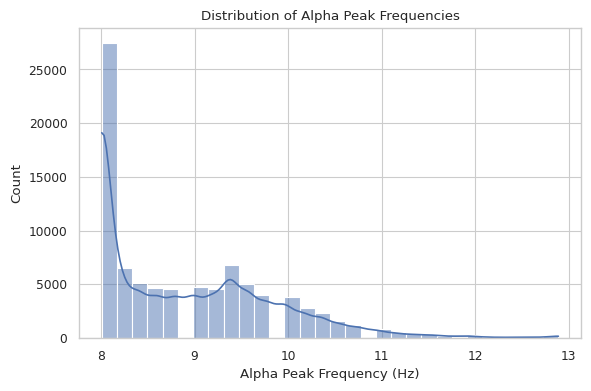

In [24]:
alpha_peaks = df_chan["alpha_peak_hz"].dropna()

plt.figure(figsize=(6,4))
sns.histplot(alpha_peaks, bins=30, kde=True)
plt.xlabel("Alpha Peak Frequency (Hz)")
plt.ylabel("Count")
plt.title("Distribution of Alpha Peak Frequencies")
plt.tight_layout()
plt.savefig(OUT / "fig_alpha_peak_distribution.png", dpi=300, bbox_inches="tight")

plt.show()


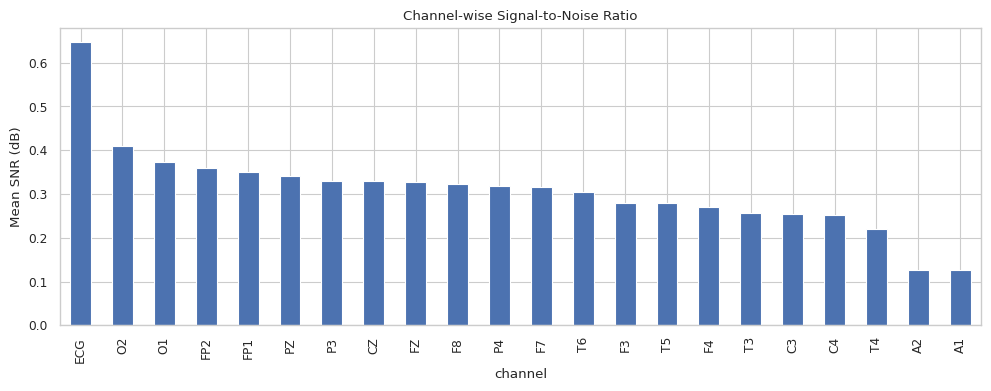

In [25]:
chan_snr = (
    df_chan.groupby("channel")["snr_db"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,4))
chan_snr.plot(kind="bar")
plt.ylabel("Mean SNR (dB)")
plt.title("Channel-wise Signal-to-Noise Ratio")
plt.tight_layout()
plt.savefig(OUT / "fig_channelwise_snr.png", dpi=300, bbox_inches="tight")

plt.show()


Abnormal files in labels: 960
Loaded abnormality CSVs: 957
Missing / skipped: 3
Example missing: ['/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/csv_fixed_channels_fczpz_updated/mh_2019_0000316.csv', '/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/csv_fixed_channels_fczpz_updated/mh_2019_0000583.csv', '/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/csv_fixed_channels_fczpz_updated/mh_2019_0001271.csv']
Saved: nmt4k_event_stats_out/event_table_raw.csv
Total events: 72638
Valid-duration events: 72636
Saved: nmt4k_event_stats_out/event_counts_unmerged.csv
Saved: nmt4k_event_stats_out/event_counts_merged.csv
Saved: nmt4k_event_stats_out/event_duration_stats_unmerged.csv
Saved: nmt4k_event_stats_out/event_duration_stats_merged.csv
Saved: nmt4k_event_stats_out/events_per_file_unmerged.csv
Saved: nmt4k_event_stats_out/events_per_file_by_merged_label.csv


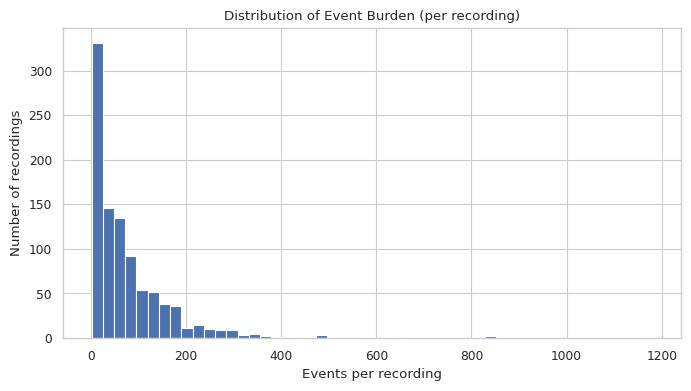

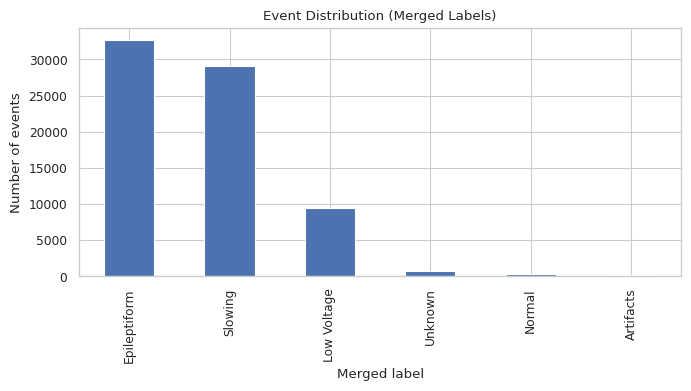

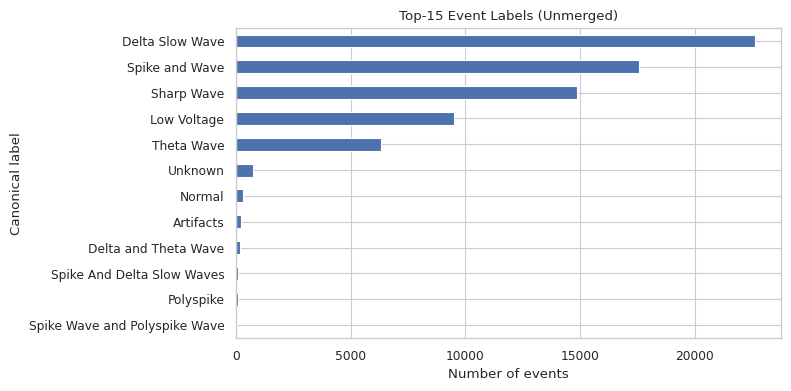


✅ Done. Outputs written to: /media/dll-1/SSD 4TB/code/misc/datastats/nmt4k_event_stats_out


In [46]:
import os, re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG (EDIT THESE)
# =========================
LABELS_CSV = "/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/labels_updated.csv"
CSV_DIR    = "/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/csv_fixed_channels_fczpz_updated"

OUT_EVT = Path("nmt4k_event_stats_out")
OUT_EVT.mkdir(parents=True, exist_ok=True)

# =========================
# 1) LABEL DICTIONARY
# =========================
ab_label_dict_detail = [
    ['Normal',
     'Beta Wave','Beta waves', 'beta waves', 'Beta Wave', 'beta activity',
     'Alpha Coma', 'alpha coma'],

    ['Sharp Wave',
     'sharp waves', 'sharp wave', 'generalized sharp waves', 'generalized sharp waves discharge', 'Sharp Wave',
     'sharp and wave', 'sharp wave discharges', 'sharp wave pre del both',
     'Triphasic Wave', 'triphasic waves', 'periodic & semiperiodic & triphasic wave',
     'periodic & semiperiodic & triphasic wave  & complexes',
     'periodic & semiperiodic & triphasic wave & sharp & slow wave & complexes',
     'semi periodic triphasic', 'semi periodic triphasic wave',
     'semiperiodic triphasic wave complexes', 'triphaic waves',
     'triphasic waves ( sharp waves)', 'triphasic waves (sharp waves)',
     'semiperiodic triphasic wavecomplexes', 'semiperiodic  triphasic wave',"triphasic waves'",
     'Burst Suppression', 'burst suppression', 'burst suppression pattern',
     'Sharp and slow Wave', 'focal sharp and slow wave', 'sharp and delta waves', 'sharp & delta wave',
     'sharp & slow wave activity', 'sharp and delta slow wave', 'sharp and slow wave activity',
     'sharp and slow wave discharges', 'slow and sharp wave', 'sharp & delta slow waves',
     'sharp and deta wave', 'sharp ans slow wave discharges', 'sharp and delta slow waves',
     'sharp and delta waves', 'sharp and delta wave', 'sharp and slow waves', 'sharp and slow wave',
     'sharp and delta slow waves'
    ],

    ['Delta Slow Wave',
     'delta slow wave', 'delta waves', 'delta slow waves', 'slowing wave',
     'generalized paroxymal delta slow waves', 'generalized paroxysmal delta slow waves',
     'generalized parosysmal delta slow waves', 'generalized delta slow waves', 'slow waves',
     'generalized delta slow waves', 'paroxysmal delta slow waves',
     'paroxysmal generalized delta slow waves', 'paroxysmal generalized deta slow waves',
     'Delta', 'delta wave', 'Delta Slow Wave', 'changegeneralized delta slow waves', 'dela slow waves',
     'delta slow waves with muscle artifacts', 'delta slowing', 'frontal delta slowing',
     'frontal slow wave', 'frontal slow wave activity', 'generalized delta slow waves discharge',
     'generalized delta slowing', 'generalized slowing', 'generalized slowing in delta range',
     'gereralized slow wave activity', 'high amplitude polymorphic slowing with multifocal spike and wave',
     'mild  slowing', 'mild generalized slowing', 'slow wave', 'slow wave activity', 'slow wave discharges',
     'delta slow waves\\', 'delta wavest', 'delta low waves', 'delta slo waves', 'delta sloww aves',
     'delta sloww waves', 'delta slowwaves', 'generaliaed slowing', 'generalize slowing',
     'generalized  slowing', 'generalizied slowing', 'generalizwd delta slowing', 'generilized slowing',
     'generlized slowing', 'generralized slowing', 'mild generilized slowing', 'mild generlized slowing',
     'delta prev','Generalized slowing mixed with Artifacts'
    ],

    ['Spike and Wave',
     '2 hertz slow spike and wave discharge', 'spike wave', 'spikes',
     'generalized paroxysmal spike and wave discharge', 'generalized paroxymal spike and wave discharge',
     'fragmented spike and wave discharge',
     'generalized paroxysmal 3 hertz spike and wave discharge',
     'generalized paroxysmal  spike and wave discharge',
     'generalized spike and wave discharge', 'generalized spike and wave discharges',
     'generalized 4 hertz spike and wave discharge', 'spike and wave', 'spike and wave discharge',
     'Generalized 3 hertz spike and wave', 'generalized 3 hertz spike and wave discharge',
     'generalized 3 hertz spike and wave activity', 'generalized 2 hertz spike and wave discharge',
     'generalized 2 hertz spike and wave', '2 hertz spike and wave discharge', 'spike and waves',
     '3 hertz fragmented spike and wave discharge', 'generalized spike and wave',
     'generalized spike and wave activity', 'spike and wave ',
     'Generalized  paroxysmal 4 hertz spike and wave discharge',
     'generalized 3.5 hertz spike and wave discharge',
     'generalized 3 hertz spike and wave discharges',
     'generalized 2 hertz spike and wave discharges', '3 hertz spike and wave discharge',
     ' 3 hertz spike and wave discharge', 'paroxysmal generalized 3.5 spike and wave discharge',
     'paroxysmal generalized 3.5 hertz spike and wave discharge', ' spike and wave discharge',
     'generalized spike  and wave discharge', 'generalized  3 hertz spike and wave discharge',
     'generalized  spike and wave discharge', 'generalized 3 hertz  spike and wave discharge',
     'spike an dwave', 'spike',
     'Paroxysmal generalized 3 hertz spike and wave discharge',
     'paroxysmal generalized spike and wave discharge',
     'paroxysmal generalized 3 hertz spike and wave discharge',
     'paroxysmal generalized 4 hertz spike and wave discharge',
     'generalized paroxysmal 3.5 spike and wave discharge',
     'spike and wave discharge 3 hertz', 'fragemented spike and wave discharge',
     'fragmented 3 hertz spike and wave discharge', 'generalized  2 hertz spike and wave discharge',
     'generalized 2 hertz  spike and wave discharge',
     'parosysmal generalized 3 hertz spike and wave discharge', 'spiek and wave',
     'generalized 2.5 hertz spike and wave discharge', 'Spike and Wave Discharge',
     '3hz spike and wave', '3hz spike and wave discharges', 'brust of spike and wave',
     'generalized 3 hertz spike and wave burst', 'generalized 3 hertzspike and wave discharge',
     'generalized periodic epileptiform discharges', 'generalized spike and wave burst',
     'generalized spike and wave dsicharge', 'generalized3 hertz spike and wave discharge',
     'spike &  wave discharges', 'spike & wave discharges', 'spike and  wave',
     'spike and wave (myoclonic jerk discharge)', 'spike and wave activity',
     'spike and wave discharges', 'spike and wave discharges\\', 'spike snd wave',
     'spike snd wave in frontal area', 'spike snd wave more porminant in frontal area',
     'spike snd wave more prominant in frontal area', 'slow spike and wave',
     'Generalized periodic epileptiform discharges\\', 'spike and wave dischages',
     'Rolandic Spikes', 'rolandic spike', 'rolandic spikes'
    ],

    ['Polyspike',
     'generalized plolyspikes discharge', 'generalized polyspike pattern',
     'polyspike and wave discharges', 'polyspike wave discharges', 'polyspikes & wave',
     'polypspikes and wave', 'generalized polyspikes discharge',
     'generalized polyspike discharge', 'generalized polyspikes discharge',
     'polyspikes discharge', 'polyspikes and wave', 'polyspikes',
     'polypspikes and wave', 'polyspike and wave'
    ],

    ['Spike Wave and Polyspike Wave',
     'generalized spike & polyspike pattern', 'generalized spike & polyspike wave',
     'spike & poilyspike wave', 'spike & polyspike',
     'spike & polyspike  and wave discharges', 'spike & polyspike and wave',
     'spike & polyspike and wave discharges',
     'spike & polyspike and wave discharges mixed with artifacts',
     'spike & polyspike and wave discharges with artifacts', 'spike & polyspike wave',
     'spike & polyspike wave discharges', 'spike & polyspike wave pattern',
     'spike &polyspike and wave discharges', 'spike / polyspike and wave discharges',
     'spike /polyspike and wave discharges', 'spike and polyspike wave',
     'spike/polyspike and wave discharges'
    ],

    ['Theta Wave',
     'theta waves', 'Theta Wave',
     'Theta Slow Wave', 'generalized slowing in theta range',
     'mild generilized slowing in theta range', 'theta slow waves', 'theta wavs'
    ],

    ['Delta and Theta Wave',
     'delta and theta waves', 'delta-theta slowing', 'frontal dela to theta slowing',
     'generalized slowing in delta to theta range', 'generalized slowing in delta-thta range'
    ],

    ['Spike And Delta Slow Waves',
     'spike and delta slow waves', 'spike and wave discharges followed by generalized slowing',
     'spike and wave discharges followed by slowing',
     'spike and wave discharges with generalized slowing'
    ],

    ['Low Voltage',
     'low voltage', 'no waveform', 'Low Voltage', 'low  voltage',
     'low voltage (no waveform)', 'low voltage (no waveform) with artifacts',
     'low voltage eeg with artifacts (no waveform)', 'low voltage eeg with muscle artifacts',
     'low voltage suppression', 'low voltage with slow background',
     'no elecctrical activity', 'no electical effects', 'no electrical activity', 'no voltage',
     'Low volage', 'No electrical activiy', 'No electrical effects', 'loew voltage',
     'low volatge (no waveform)', 'low voltagev', 'loww voltage',
     'no electrical avtivity', 'no electrtical activity', 'v'
    ],

    ['Artifacts',
     'Artifacts', 'artifact', 'blink artifacts', 'frontal area artifacts',
     'Artifracts', 'articats', 'artifacds', 'biink artifacts', 'bilink artifacts', 'bilnk artifacts'
    ],

    ['Unknown',
     'No Comment', 'delete previous', 'nan', 'Unknown'
    ]
]

# =========================
# 2) MERGE RULES (COARSE)
# =========================
merge_by_index = {
    "Slowing": [2, 6, 7],            # Delta Slow Wave, Theta Wave, Delta+Theta
    "Epileptiform": [1, 3, 4, 5, 8], # Sharp, Spike&Wave, Polyspike, Mixed, Spike+DeltaSlow
}

# Build canonical->merged map
merge_map = {}
for new_label, idxs in merge_by_index.items():
    for idx in idxs:
        canonical = ab_label_dict_detail[idx][0]
        merge_map[canonical] = new_label

# Keep other canonical labels as-is (optional, but helps keep them visible)
# e.g. Low Voltage, Artifacts, Unknown, Normal remain unchanged.

# =========================
# 3) NORMALIZE + COMMENT->CANONICAL MAP
# =========================
def normalize_text(s):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return ""
    s = str(s).strip().strip('"').strip("'")
    s = re.sub(r"\s+", " ", s)
    return s.lower()

variant_to_canonical = {}
for group in ab_label_dict_detail:
    canonical = group[0]
    for v in group:
        variant_to_canonical[normalize_text(v)] = canonical

def map_comment_to_label(comment):
    key = normalize_text(comment)
    if key == "":
        return "Unknown"
    return variant_to_canonical.get(key, "Unknown")

# =========================
# 4) LOAD ABNORMAL FILE LIST
# =========================
labels_df = pd.read_csv(LABELS_CSV)

# Expect columns: file_name, label
labels_df["label"] = labels_df["label"].astype(str).str.lower()
abnormal_files = labels_df.loc[labels_df["label"] == "abnormal", "file_name"].astype(str).tolist()

print(f"Abnormal files in labels: {len(abnormal_files)}")

# =========================
# 5) READ CSVs + BUILD EVENT TABLE
# =========================
def parse_hms_ms_to_sec(x):
    """
    Parse time like:
      HH:MM:SS
      HH:MM:SS:ms
      HH:MM:SS.ms
    Return seconds (float) or NaN.
    """
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.nan
    s = str(x).strip()
    if not s:
        return np.nan
    s = s.replace(".", ":")
    parts = s.split(":")
    try:
        if len(parts) == 3:
            hh, mm, ss = parts
            return int(hh)*3600 + int(mm)*60 + float(ss)
        if len(parts) == 4:
            hh, mm, ss, ms = parts
            return int(hh)*3600 + int(mm)*60 + int(ss) + (int(ms)/1000.0)
    except:
        return np.nan
    return np.nan

rows = []
missing = []

needed_cols = ["File Start", "Start time", "End time", "Channel names", "Comment"]

for fname in abnormal_files:
    path = os.path.join(CSV_DIR, f"{fname}.csv")
    if not os.path.exists(path):
        missing.append(path)
        continue

    d = pd.read_csv(path)

    # ensure columns exist
    for col in needed_cols:
        if col not in d.columns:
            d[col] = np.nan

    # canonical + merged
    d["label_canonical"] = d["Comment"].apply(map_comment_to_label)
    d["label_merged"]    = d["label_canonical"].replace(merge_map)

    # parse times
    d["start_sec"] = d["Start time"].apply(parse_hms_ms_to_sec)
    d["end_sec"]   = d["End time"].apply(parse_hms_ms_to_sec)

    # duration
    d["duration_sec"] = d["end_sec"] - d["start_sec"]

    # keep needed columns
    d["file_name"] = fname

    rows.append(d[[
        "file_name", "File Start", "Start time", "End time",
        "start_sec", "end_sec", "duration_sec",
        "Channel names", "Comment", "label_canonical", "label_merged"
    ]])

event_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

print(f"Loaded abnormality CSVs: {len(abnormal_files) - len(missing)}")
print(f"Missing / skipped: {len(missing)}")
if missing:
    print("Example missing:", missing[:3])

if event_df.empty:
    raise RuntimeError("No event rows loaded. Check CSV_DIR and labels_updated.csv columns.")

# Save raw event table
event_df.to_csv(OUT_EVT/"event_table_raw.csv", index=False)
print("Saved:", OUT_EVT/"event_table_raw.csv")

# =========================
# 6) BASIC CLEAN FILTERS
# =========================
# valid duration > 0 and not nan
event_df["valid_duration"] = event_df["duration_sec"].notna() & (event_df["duration_sec"] > 0)

valid_events = event_df[event_df["valid_duration"]].copy()

print("Total events:", len(event_df))
print("Valid-duration events:", len(valid_events))

# =========================
# 7) ANALYSIS (UNMERGED + MERGED)
# =========================
# A) counts
counts_unmerged = valid_events["label_canonical"].value_counts()
counts_merged   = valid_events["label_merged"].value_counts()

counts_unmerged.to_csv(OUT_EVT/"event_counts_unmerged.csv", header=["count"])
counts_merged.to_csv(OUT_EVT/"event_counts_merged.csv", header=["count"])

print("Saved:", OUT_EVT/"event_counts_unmerged.csv")
print("Saved:", OUT_EVT/"event_counts_merged.csv")

# B) duration stats per label
dur_unmerged = (
    valid_events.groupby("label_canonical")["duration_sec"]
    .agg(["count","mean","median","std","min","max"])
    .sort_values("count", ascending=False)
)
dur_merged = (
    valid_events.groupby("label_merged")["duration_sec"]
    .agg(["count","mean","median","std","min","max"])
    .sort_values("count", ascending=False)
)

dur_unmerged.to_csv(OUT_EVT/"event_duration_stats_unmerged.csv")
dur_merged.to_csv(OUT_EVT/"event_duration_stats_merged.csv")

print("Saved:", OUT_EVT/"event_duration_stats_unmerged.csv")
print("Saved:", OUT_EVT/"event_duration_stats_merged.csv")

# C) per-file event burden (both)
per_file_unmerged = valid_events.groupby("file_name").size().rename("n_events").reset_index()
per_file_merged = (
    valid_events.groupby(["file_name","label_merged"]).size()
    .rename("n_events").reset_index()
)

per_file_unmerged.to_csv(OUT_EVT/"events_per_file_unmerged.csv", index=False)
per_file_merged.to_csv(OUT_EVT/"events_per_file_by_merged_label.csv", index=False)

print("Saved:", OUT_EVT/"events_per_file_unmerged.csv")
print("Saved:", OUT_EVT/"events_per_file_by_merged_label.csv")

# =========================
# 8) PLOTS (SAVED)
# =========================
# Histogram: events per recording
plt.figure(figsize=(7,4))
plt.hist(per_file_unmerged["n_events"], bins=50)
plt.xlabel("Events per recording")
plt.ylabel("Number of recordings")
plt.title("Distribution of Event Burden (per recording)")
plt.tight_layout()
plt.savefig(OUT_EVT/"plot_events_per_recording_hist.png", dpi=300)
plt.show()

# Bar: merged label counts
plt.figure(figsize=(7,4))
counts_merged.sort_values(ascending=False).plot(kind="bar")
plt.xlabel("Merged label")
plt.ylabel("Number of events")
plt.title("Event Distribution (Merged Labels)")
plt.tight_layout()
plt.savefig(OUT_EVT/"plot_event_distribution_merged.png", dpi=300)
plt.show()

# Bar: top-15 unmerged labels
plt.figure(figsize=(8,4))
counts_unmerged.head(15).sort_values(ascending=True).plot(kind="barh")
plt.xlabel("Number of events")
plt.ylabel("Canonical label")
plt.title("Top-15 Event Labels (Unmerged)")
plt.tight_layout()
plt.savefig(OUT_EVT/"plot_top15_event_distribution_unmerged.png", dpi=300)
plt.show()

print("\n✅ Done. Outputs written to:", OUT_EVT.resolve())


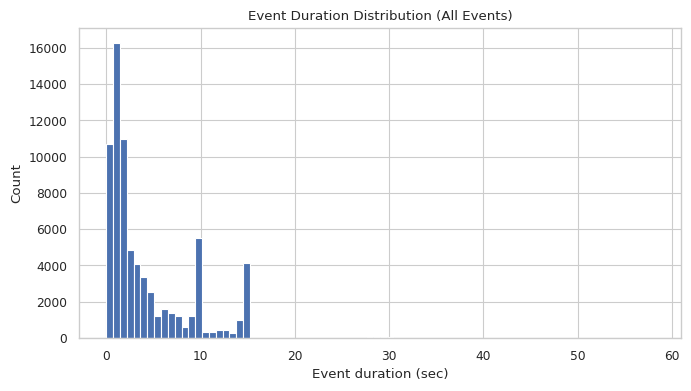

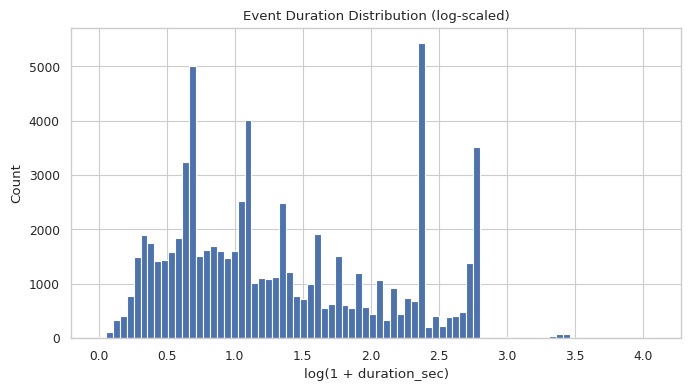

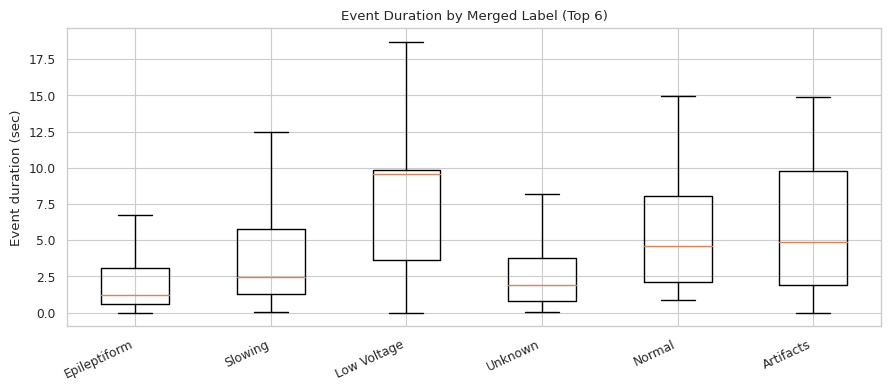

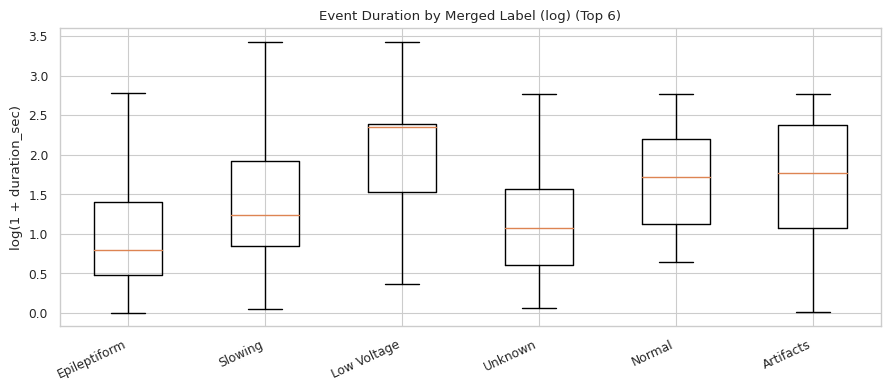

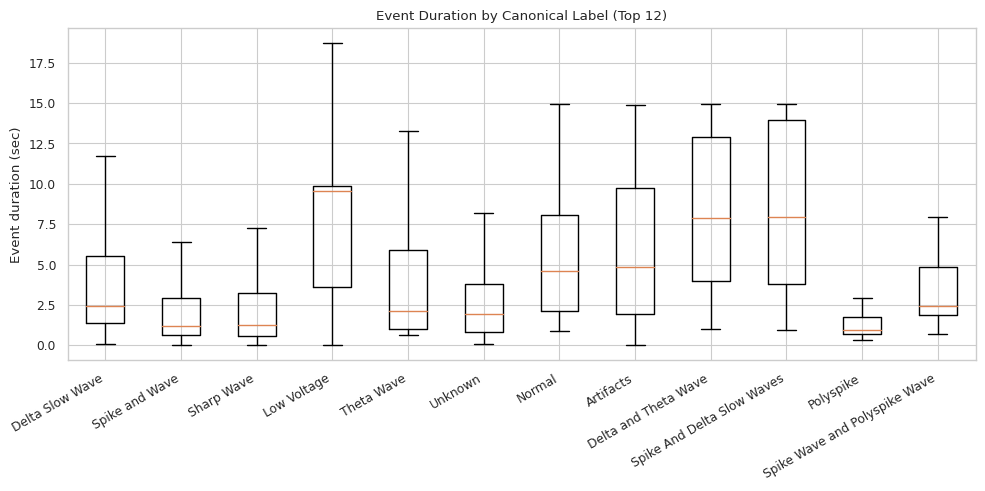

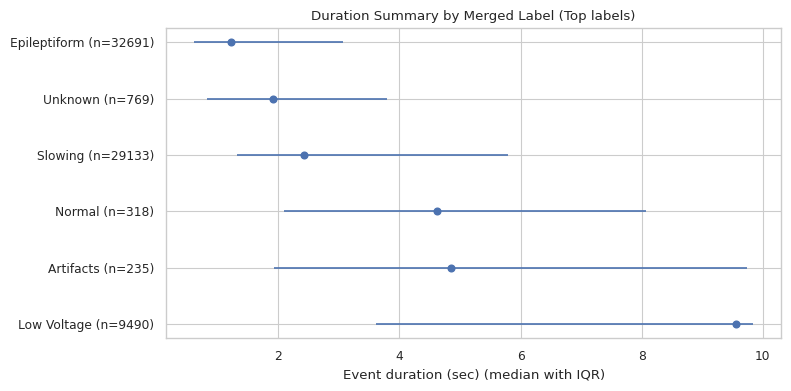

✅ Saved duration plots into: nmt4k_event_stats_out


In [47]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Helper
# -------------------------
def safe_log1p(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    x = x[x >= 0]
    return np.log1p(x)

# =========================
# 1) Duration histogram (all events)
# =========================
dur_all = valid_events["duration_sec"].dropna()
dur_all = dur_all[(dur_all > 0) & np.isfinite(dur_all)]

plt.figure(figsize=(7,4))
plt.hist(dur_all, bins=80)
plt.xlabel("Event duration (sec)")
plt.ylabel("Count")
plt.title("Event Duration Distribution (All Events)")
plt.tight_layout()
plt.savefig(OUT_EVT/"plot_event_duration_hist_all.png", dpi=300)
plt.show()

# Log-scale histogram (often more readable for heavy-tail durations)
plt.figure(figsize=(7,4))
plt.hist(safe_log1p(dur_all), bins=80)
plt.xlabel("log(1 + duration_sec)")
plt.ylabel("Count")
plt.title("Event Duration Distribution (log-scaled)")
plt.tight_layout()
plt.savefig(OUT_EVT/"plot_event_duration_hist_all_log.png", dpi=300)
plt.show()

# =========================
# 2) Boxplot by label (MERGED) - best for paper
#    (top-K labels by count)
# =========================
K = 8  # change if you want more/less
top_merged = (
    valid_events["label_merged"]
    .value_counts()
    .head(K)
    .index
    .tolist()
)

data = []
labels = []
for lab in top_merged:
    x = valid_events.loc[valid_events["label_merged"] == lab, "duration_sec"].dropna()
    x = x[(x > 0) & np.isfinite(x)]
    if len(x) == 0:
        continue
    data.append(x.values)
    labels.append(lab)

plt.figure(figsize=(9,4))
plt.boxplot(data, labels=labels, showfliers=False)
plt.ylabel("Event duration (sec)")
plt.title(f"Event Duration by Merged Label (Top {len(labels)})")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(OUT_EVT/"plot_box_duration_by_merged_topK.png", dpi=300)
plt.show()

# Optional: same boxplot in log space (more stable if long tails)
data_log = [safe_log1p(x) for x in data]
plt.figure(figsize=(9,4))
plt.boxplot(data_log, labels=labels, showfliers=False)
plt.ylabel("log(1 + duration_sec)")
plt.title(f"Event Duration by Merged Label (log) (Top {len(labels)})")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(OUT_EVT/"plot_box_duration_by_merged_topK_log.png", dpi=300)
plt.show()

# =========================
# 3) Boxplot by label (UNMERGED) - top-K canonical
# =========================
K2 = 12
top_unmerged = (
    valid_events["label_canonical"]
    .value_counts()
    .head(K2)
    .index
    .tolist()
)

data2 = []
labels2 = []
for lab in top_unmerged:
    x = valid_events.loc[valid_events["label_canonical"] == lab, "duration_sec"].dropna()
    x = x[(x > 0) & np.isfinite(x)]
    if len(x) == 0:
        continue
    data2.append(x.values)
    labels2.append(lab)

plt.figure(figsize=(10,5))
plt.boxplot(data2, labels=labels2, showfliers=False)
plt.ylabel("Event duration (sec)")
plt.title(f"Event Duration by Canonical Label (Top {len(labels2)})")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUT_EVT/"plot_box_duration_by_unmerged_topK.png", dpi=300)
plt.show()

# =========================
# 4) Duration summary plot (median + IQR) for merged labels (top-K)
# =========================
# Compute median + quartiles for a cleaner "paper-style" plot
summary = []
for lab in top_merged:
    x = valid_events.loc[valid_events["label_merged"] == lab, "duration_sec"].dropna()
    x = x[(x > 0) & np.isfinite(x)]
    if len(x) == 0:
        continue
    q1 = np.percentile(x, 25)
    med = np.percentile(x, 50)
    q3 = np.percentile(x, 75)
    summary.append((lab, q1, med, q3, len(x)))

summary_df = (
    pd.DataFrame(summary, columns=["label","q1","median","q3","n"])
    .sort_values("median", ascending=False)
)

plt.figure(figsize=(8,4))
y = np.arange(len(summary_df))
plt.errorbar(
    summary_df["median"].values,
    y,
    xerr=[
        (summary_df["median"] - summary_df["q1"]).values,
        (summary_df["q3"] - summary_df["median"]).values
    ],
    fmt="o"
)
plt.yticks(y, [f"{l} (n={n})" for l, n in zip(summary_df["label"], summary_df["n"])])
plt.xlabel("Event duration (sec) (median with IQR)")
plt.title("Duration Summary by Merged Label (Top labels)")
plt.tight_layout()
plt.savefig(OUT_EVT/"plot_duration_median_iqr_merged_topK.png", dpi=300)
plt.show()

print("✅ Saved duration plots into:", OUT_EVT)
